# Notebook 02: Sequence layer, readout, and training

Notebook 01 established that the dynamics are correct. This one puts them to work: wrap the
oscillator bank in a readout, train it, and see what breaks.

Two things needed fix, both were predicted by notebook 01:

1. **Input gain.** across a 10-100 Hz bank the
   fastest units respond 100x more weakly than the slowest. With a flat `W_in` the whole
   population produces states of order $10^{-6}$, the softmax is uniform, and no gradient flows.
   Scaling each row of `W_in` by $2\zeta\omega^2$ fixes it.
2. **Pooling.** A sinusoidal response time-averages to approximately zero, so mean-pooling
   destroys exactly the signal we want. The class information is in response *power*.

**Contents**

1. The sequence model, and what sequence length costs you
2. Warm-up task: frequency discrimination
3. The two fixes, demonstrated
4. Training loop
5. Sequential MNIST, row-wise
6. Frozen vs learned $(\omega, \zeta)$
7. Sequential MNIST, pixel-wise


In [5]:
import sys, subprocess
from pathlib import Path

import time
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

from horn.core import step as horn_step, init_state
from horn.model import (init_net, forward, loss_and_acc, freeze_oscillators,
                        usable_band, log_spaced_bands, band_summary, TWOPI)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
print("jax", jax.__version__, jax.devices())

jax 0.11.0 [CpuDevice(id=0)]


## 1. The sequence model

A HORN layer plus a linear readout. The only real design choices are how the trajectory is
collapsed into a fixed-size vector, and what the readout reads.

**Read $(x, v/\omega)$, not $(x, v)$.** For a harmonic oscillator $v \sim \omega x$, so at 100 Hz the
raw velocity is ~600x the position. A readout given both would be dominated by velocity purely
through units. Dividing by $\omega$ puts them on the same scale; these are also the coordinates in
which $x^2 + (v/\omega)^2$ is proportional to energy.

**Time is physical.** A sequence of $L$ steps is treated as spanning a real duration, so
$dt = T_{seq}/L$ and $\omega$ stays in Hz. Everything from notebook 01 carries over.

### What sequence length costs you

Two walls, from `usable_band()`:

- **slow wall**: a unit must complete at least ~1 cycle inside the sequence, else it never
  oscillates and is just a leaky integrator. $f_{min} = 1/(L\,dt)$
- **fast wall**: integration needs ~10 samples per period. $f_{max} = 1/(10\,dt)$

Their ratio is $f_{max}/f_{min} = L/10$ — set by **sequence length alone**, independent of $dt$.

This decides whether a nested band structure is representable at all. A 1:6 theta-gamma nesting
needs $L \gtrsim 60$. Row-wise MNIST, at 28 steps, simply cannot hold it.

In [6]:
print(f"{'task':>22} {'L':>6} {'dt (s)':>9} {'f_min':>8} {'f_max':>8} {'ratio':>7}  nesting?")
for name, L, T_seq in [("MNIST row-wise", 28, 0.28),
                       ("MNIST pixel-wise", 784, 1.0),
                       ("freq. discrimination", 100, 0.1)]:
    dt = T_seq / L
    lo, hi = usable_band(L, dt)
    ok = "1:6 fits" if hi / lo >= 6 else "1:6 DOES NOT fit"
    print(f"{name:>22} {L:>6} {dt:>9.5f} {lo:>8.1f} {hi:>8.1f} {hi/lo:>7.1f}  {ok}")

                  task      L    dt (s)    f_min    f_max   ratio  nesting?
        MNIST row-wise     28   0.01000      3.6     10.0     2.8  1:6 DOES NOT fit
      MNIST pixel-wise    784   0.00128      1.0     78.4    78.4  1:6 fits
  freq. discrimination    100   0.00100     10.0    100.0    10.0  1:6 fits


## 2. Warm-up: frequency discrimination

Before MNIST, a task oscillators should be *good* at: classify which of three frequencies
(15 / 30 / 60 Hz) a noisy sinusoid carries. Random phase per example, so the answer cannot come
from a fixed time offset.

If a bank of resonators cannot do this, nothing downstream is worth debugging.

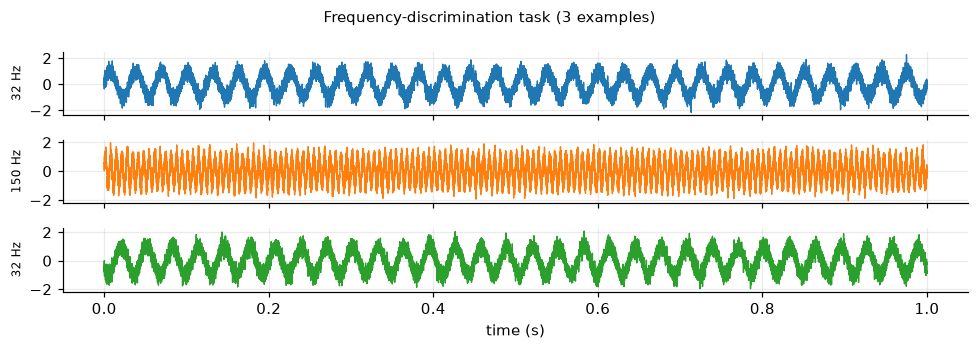

usable band 1.0-2000.0 Hz; all three classes sit inside it


In [15]:
L_F, DT_F = 20000, 5e-5                     # 20000 samples at 20 kHz = 1 s
F_LO, F_HI = usable_band(L_F, DT_F)
CLASSES = jnp.array([8.0, 32.0, 150.0])     # frequencies in Hz, all inside the usable band

def freq_batch(key, n, noise=0.3):
    """Noisy sinusoid at one of CLASSES, random phase. -> (L, n, 1), (n,)"""
    k1, k2, k3 = jax.random.split(key, 3)
    y = jax.random.randint(k1, (n,), 0, len(CLASSES))
    phase = jax.random.uniform(k2, (n,)) * 2 * jnp.pi
    t = jnp.arange(1, L_F + 1) * DT_F
    f = CLASSES[y]
    x = jnp.sin(2 * jnp.pi * f[None, :] * t[:, None] + phase[None, :])
    x = x + noise * jax.random.normal(k3, (L_F, n))
    return x[..., None], y

xb, yb = freq_batch(jax.random.PRNGKey(0), 3)
fig, ax = plt.subplots(3, 1, figsize=(9, 3.2), sharex=True)
for i in range(3):
    ax[i].plot(np.arange(L_F) * DT_F, np.asarray(xb[:, i, 0]), lw=0.9, color=f"C{i}")
    ax[i].set_ylabel(f"{float(CLASSES[yb[i]]):.0f} Hz", fontsize=8)
ax[-1].set_xlabel("time (s)")
fig.suptitle("Frequency-discrimination task (3 examples)", fontsize=10)
plt.tight_layout(); plt.show()
print(f"usable band {F_LO:.1f}-{F_HI:.1f} Hz; all three classes sit inside it")

## 3. The two fixes, demonstrated

### 3a. Input gain

Build the same network twice — flat `W_in` versus `W_in` scaled by $2\zeta\omega^2$ — and look at
the magnitude of everything.

In [17]:
N_OSC = 24
f_bank = log_spaced_bands(N_OSC, F_LO, F_HI)

t = jnp.arange(1, L_F + 1) * DT_F
probe = (jnp.sin(2 * jnp.pi * 30.0 * t)[:, None, None]) * jnp.ones((1, 1, 1))
probe_y = jnp.zeros((1,), int)

print(f"{'input_gain':>12} {'mean|x|':>11} {'mean|logit|':>12} {'loss':>9} {'grad readout':>14} {'grad W_rec':>12}")
for gain in ["flat", "normalised"]:
    p = init_net(jax.random.PRNGKey(0), 1, N_OSC, 3, f_hz=f_bank, zeta=0.15,
                 input_gain=gain, pool="rms")
    _, (xs, vs) = jax.lax.scan(
        lambda c, u: (lambda new, _o: (new, (new.x, new.v)))(*horn_step(p.horn, c, u, DT_F)),
        init_state(N_OSC, batch=1), probe)
    lg = forward(p, probe, DT_F, pool="rms")
    l = loss_and_acc(p, probe, probe_y, DT_F, "rms")[0]
    g = jax.grad(lambda q: loss_and_acc(q, probe, probe_y, DT_F, "rms")[0])(p)
    print(f"{gain:>12} {float(jnp.abs(xs).mean()):>11.3e} {float(jnp.abs(lg).mean()):>12.3e} "
          f"{float(l):>9.6f} {float(jnp.linalg.norm(g.readout.W)):>14.3e} "
          f"{float(jnp.linalg.norm(g.horn.W_rec)):>12.3e}")
print(f"\nln(3) = {np.log(3):.6f}  <- a loss pinned here means the softmax is uniform:")

  input_gain     mean|x|  mean|logit|      loss   grad readout   grad W_rec
        flat   4.260e-06    1.047e-05  1.098598      8.968e-05    1.615e-07
  normalised   1.256e-02    1.685e-02  1.113237      1.149e-01    1.916e-05

ln(3) = 1.098612  <- a loss pinned here means the softmax is uniform:


### 3b. Pooling

A sinusoid averages to zero over time. The longer the sequence and the higher the frequency, the
closer to zero the mean gets — so mean-pooling throws away more of the signal exactly where the
oscillator bank is working hardest.

In [19]:
p = init_net(jax.random.PRNGKey(0), 1, N_OSC, 3, f_hz=f_bank, zeta=0.15)
print(f"{'drive':>8} {'|mean(x)|':>12} {'rms(x)':>10} {'mean/rms':>10}")
for f in [8.0, 80.0, 200.0]:
    u = (jnp.sin(2 * jnp.pi * f * t)[:, None, None]) * jnp.ones((1, 1, 1))
    _, (xs, vs) = jax.lax.scan(
        lambda c, uu: (lambda new, _o: (new, (new.x, new.v)))(*horn_step(p.horn, c, uu, DT_F)),
        init_state(N_OSC, batch=1), u)
    m = float(jnp.abs(xs.mean(0)).mean()); r = float(jnp.sqrt((xs ** 2).mean(0)).mean())
    print(f"{f:>7.0f}H {m:>12.5f} {r:>10.5f} {m / r:>10.3f}")
print("\nThe ratio falls with frequency: mean-pooling is worst for the fastest units.")

   drive    |mean(x)|     rms(x)   mean/rms
      8H      0.00024    0.01844      0.013
     80H      0.00004    0.01103      0.004
    200H      0.00002    0.00821      0.002

The ratio falls with frequency: mean-pooling is worst for the fastest units.


## 4. Training loop

Standard Adam, with two things that matter for oscillators:

- **gradient clipping by global norm.** Oscillatory recurrence produces occasional very large
  gradients; without clipping a single bad batch can destroy the run.
- **$\omega$ and $\zeta$ are stored as logs**, so they cannot cross zero into negative damping no
  matter what the optimiser does. Implemented in `core.py`.

In [20]:
def make_train_step(opt, dt, pool, freeze=False):
    """Returns a jitted update. `freeze` zeroes the gradients on log_omega/log_zeta."""
    @jax.jit
    def train_step(params, opt_state, x, y):
        (loss, acc), grads = jax.value_and_grad(
            lambda q: loss_and_acc(q, x, y, dt, pool), has_aux=True)(params)
        if freeze:
            grads = freeze_oscillators(grads)
        gnorm = optax.global_norm(grads)
        updates, opt_state = opt.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), opt_state, loss, acc, gnorm
    return train_step


def train(params, batch_fn, dt, pool, steps=400, batch=64, lr=3e-3,
          freeze=False, seed=0, eval_every=50, log=True):
    opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr))
    opt_state = opt.init(params)
    train_step = make_train_step(opt, dt, pool, freeze)
    key = jax.random.PRNGKey(seed)
    hist = {"step": [], "loss": [], "acc": [], "gnorm": []}
    t0 = time.time()
    for i in range(steps):
        key, kb = jax.random.split(key)
        x, y = batch_fn(kb, batch)
        params, opt_state, loss, acc, gnorm = train_step(params, opt_state, x, y)
        if i % eval_every == 0 or i == steps - 1:
            hist["step"].append(i); hist["loss"].append(float(loss))
            hist["acc"].append(float(acc)); hist["gnorm"].append(float(gnorm))
            if log and (i % (eval_every * 4) == 0 or i == steps - 1):
                print(f"    step {i:>5}  loss {float(loss):.4f}  acc {float(acc):.3f}  |g| {float(gnorm):.2e}")
    if log:
        print(f"    [{time.time() - t0:.1f}s]")
    return params, hist

  pool = mean
    test acc 0.335
  pool = rms
    test acc 1.000
  pool = last
    test acc 0.323


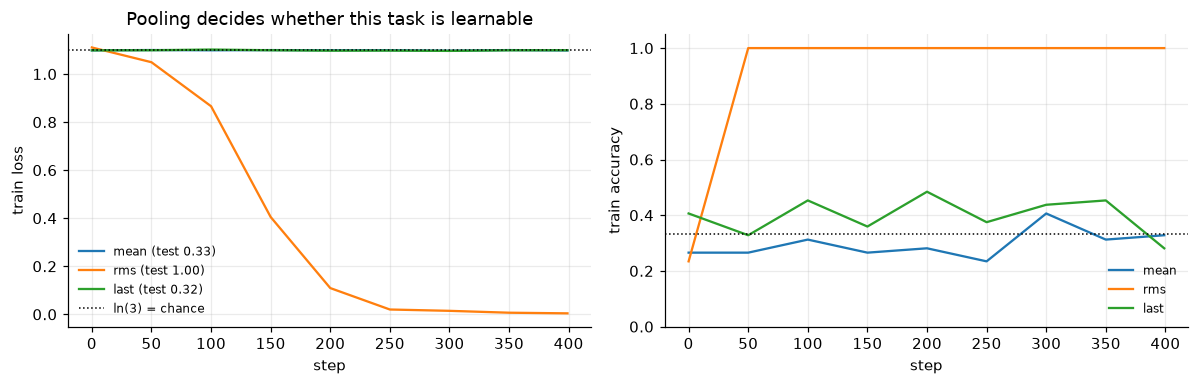

In [21]:
results = {}
for pool in ["mean", "rms", "last"]:
    print(f"  pool = {pool}")
    p0 = init_net(jax.random.PRNGKey(0), 1, N_OSC, 3, f_hz=f_bank, zeta=0.15, pool=pool)
    p_end, hist = train(p0, freq_batch, DT_F, pool, steps=400, log=False)
    xt, yt = freq_batch(jax.random.PRNGKey(999), 1024)
    acc = float(loss_and_acc(p_end, xt, yt, DT_F, pool)[1])
    results[pool] = (hist, acc)
    print(f"    test acc {acc:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for pool, (h, acc) in results.items():
    ax[0].plot(h["step"], h["loss"], label=f"{pool} (test {acc:.2f})")
    ax[1].plot(h["step"], h["acc"], label=pool)
ax[0].axhline(np.log(3), color="k", ls=":", lw=1, label="ln(3) = chance")
ax[0].set(xlabel="step", ylabel="train loss", title="Pooling decides whether this task is learnable")
ax[1].axhline(1/3, color="k", ls=":", lw=1)
ax[1].set(xlabel="step", ylabel="train accuracy", ylim=(0, 1.05))
ax[0].legend(fontsize=8, frameon=False); ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 5. Sequential MNIST, row-wise

28 steps of 28 features. Fast enough to debug against, but note from section 1 that 28 steps give
a usable band ratio of only 2.8 — this task cannot exercise a nested band structure. It is a
correctness check, not the real benchmark.

In [ ]:
def load_mnist(cache=None):
    """Load MNIST as (train_x, train_y, test_x, test_y), float32 in [0,1].

    Tries a local cache first, then two mirrors. Falls back to synthetic data so the
    notebook still runs end to end - but LOUDLY, because a synthetic result is not a result.
    """
    cache = Path(cache) if cache is not None else DATA_DIR
    cache.mkdir(parents=True, exist_ok=True)
    npz = cache / "mnist.npz"
    if npz.exists():
        d = np.load(npz)
        return d["xtr"], d["ytr"], d["xte"], d["yte"]

    import gzip, urllib.request
    files = {"xtr": "train-images-idx3-ubyte.gz", "ytr": "train-labels-idx1-ubyte.gz",
             "xte": "t10k-images-idx3-ubyte.gz",  "yte": "t10k-labels-idx1-ubyte.gz"}
    mirrors = ["https://storage.googleapis.com/cvdf-datasets/mnist/",
               "https://ossci-datasets.s3.amazonaws.com/mnist/"]
    out = {}
    try:
        for k, fn in files.items():
            raw = None
            for m in mirrors:
                try:
                    with urllib.request.urlopen(m + fn, timeout=30) as r:
                        raw = gzip.decompress(r.read())
                    break
                except Exception:
                    continue
            if raw is None:
                raise RuntimeError(f"could not fetch {fn}")
            if k.startswith("x"):
                out[k] = np.frombuffer(raw, np.uint8, offset=16).reshape(-1, 28, 28).astype(np.float32) / 255.0
            else:
                out[k] = np.frombuffer(raw, np.uint8, offset=8).astype(np.int32)
        np.savez_compressed(npz, **out)
        print(f"MNIST downloaded and cached to {npz}")
        return out["xtr"], out["ytr"], out["xte"], out["yte"]
    except Exception as e:
        print("!" * 70)
        print(f"MNIST DOWNLOAD FAILED ({e}).")
        print("Falling back to SYNTHETIC data. Numbers below are meaningless -")
        print(f"fix the download or drop mnist.npz into {cache}/ before reporting anything.")
        print("!" * 70)
        rng = np.random.default_rng(0)
        xtr = rng.random((2000, 28, 28), dtype=np.float32); ytr = rng.integers(0, 10, 2000).astype(np.int32)
        xte = rng.random((500, 28, 28), dtype=np.float32);  yte = rng.integers(0, 10, 500).astype(np.int32)
        return xtr, ytr, xte, yte


XTR, YTR, XTE, YTE = load_mnist()
print("train", XTR.shape, "test", XTE.shape)

In [ ]:
ROW_L, ROW_T = 28, 0.28                 # 28 rows spanning 0.28 s
ROW_DT = ROW_T / ROW_L
ROW_LO, ROW_HI = usable_band(ROW_L, ROW_DT)
print(f"row-wise: dt={ROW_DT*1000:.1f} ms, usable band {ROW_LO:.1f}-{ROW_HI:.1f} Hz")

XTR_ROW = jnp.asarray(XTR.transpose(1, 0, 2))       # (28 rows, N, 28 cols)
XTE_ROW = jnp.asarray(XTE.transpose(1, 0, 2))
YTR_J, YTE_J = jnp.asarray(YTR), jnp.asarray(YTE)

def row_batch(key, n):
    idx = jax.random.randint(key, (n,), 0, XTR_ROW.shape[1])
    return XTR_ROW[:, idx, :], YTR_J[idx]

def evaluate(params, X, Y, dt, pool, chunk=500):
    accs = []
    for i in range(0, X.shape[1], chunk):
        accs.append(float(loss_and_acc(params, X[:, i:i+chunk], Y[i:i+chunk], dt, pool)[1])
                    * X[:, i:i+chunk].shape[1])
    return sum(accs) / X.shape[1]

N_OSC_M, POOL_M = 96, "meanrms"
p0_row = init_net(jax.random.PRNGKey(0), 28, N_OSC_M, 10,
                  f_hz=log_spaced_bands(N_OSC_M, ROW_LO, ROW_HI), zeta=0.15, pool=POOL_M)
p_row, h_row = train(p0_row, row_batch, ROW_DT, POOL_M, steps=1500, batch=128, lr=3e-3)
print(f"  row-wise sMNIST test accuracy: {evaluate(p_row, XTE_ROW, YTE_J, ROW_DT, POOL_M):.4f}")

## 6. Frozen vs learned $(\omega, \zeta)$

Notebook 01 argued that gradient descent through oscillatory dynamics is unlikely to move
$\omega$ and $\zeta$ far, so whatever range of timescales a task needs must be reachable from the
initialisation. This tests it directly: identical architecture and initialisation, one run with
the oscillator constants frozen and one with them free.

If the frozen run matches the learned run, then the bank is doing its work through
$W_{in}$/$W_{rec}$/readout and the oscillator constants are effectively hyperparameters, not
parameters. That would make **initialisation the design decision**, which is exactly the claim.

In [ ]:
p0 = init_net(jax.random.PRNGKey(0), 28, N_OSC_M, 10,
              f_hz=log_spaced_bands(N_OSC_M, ROW_LO, ROW_HI), zeta=0.15, pool=POOL_M)

print("  frozen omega/zeta:")
p_frozen, h_frozen = train(p0, row_batch, ROW_DT, POOL_M, steps=1500, batch=128, freeze=True)
acc_frozen = evaluate(p_frozen, XTE_ROW, YTE_J, ROW_DT, POOL_M)

print("  learned omega/zeta:")
p_learned, h_learned = train(p0, row_batch, ROW_DT, POOL_M, steps=1500, batch=128, freeze=False)
acc_learned = evaluate(p_learned, XTE_ROW, YTE_J, ROW_DT, POOL_M)

print(f"\n  frozen  test acc {acc_frozen:.4f}")
print(f"  learned test acc {acc_learned:.4f}   (difference {acc_learned - acc_frozen:+.4f})")

s0, sl = band_summary(p0), band_summary(p_learned)
rel = jnp.abs(sl["f_hz"] - s0["f_hz"]) / s0["f_hz"]
print(f"\n  how far did the bank actually move?")
print(f"    f_hz : {float(s0['f_hz'].min()):.2f}-{float(s0['f_hz'].max()):.2f}"
      f"  ->  {float(sl['f_hz'].min()):.2f}-{float(sl['f_hz'].max()):.2f} Hz")
print(f"    median |df|/f = {float(jnp.median(rel))*100:.1f}%,  max = {float(rel.max())*100:.1f}%")
print(f"    zeta : {float(s0['zeta'][0]):.3f}  ->  {float(sl['zeta'].min()):.3f}-{float(sl['zeta'].max()):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(h_frozen["step"], h_frozen["loss"], label=f"frozen ({acc_frozen:.3f})")
ax[0].plot(h_learned["step"], h_learned["loss"], label=f"learned ({acc_learned:.3f})")
ax[0].set(xlabel="step", ylabel="train loss", title="Frozen vs learned oscillator constants")
ax[0].legend(fontsize=8, frameon=False)
ax[1].scatter(np.asarray(s0["f_hz"]), np.asarray(sl["f_hz"]), s=12, color="C0")
lim = [float(s0["f_hz"].min()) * 0.9, float(s0["f_hz"].max()) * 1.1]
ax[1].plot(lim, lim, "k:", lw=1)
ax[1].set(xlabel="initial f (Hz)", ylabel="final f (Hz)", title="Did omega move?", xscale="log", yscale="log")
ax[2].scatter(np.asarray(s0["f_hz"]), np.asarray(sl["zeta"]), s=12, color="C1")
ax[2].axhline(0.15, color="k", ls=":", lw=1)
ax[2].set(xlabel="initial f (Hz)", ylabel="final zeta", title="Did zeta move?", xscale="log")
plt.tight_layout(); plt.show()

## 7. Sequential MNIST, pixel-wise

784 steps of one feature — the standard benchmark, and the one published HORN numbers use.
BPTT memory is 28x the row-wise case, so expect this to be substantially slower.

This is also the first setting where the band structure has room: 784 steps give a usable ratio
of ~78, so theta through gamma all fit and a nested architecture becomes representable.

In [ ]:
PIX_L, PIX_T = 784, 1.0
PIX_DT = PIX_T / PIX_L
PIX_LO, PIX_HI = usable_band(PIX_L, PIX_DT)
print(f"pixel-wise: dt={PIX_DT*1000:.3f} ms, usable band {PIX_LO:.1f}-{PIX_HI:.1f} Hz "
      f"(ratio {PIX_HI/PIX_LO:.0f}) -> a 1:6 nesting fits comfortably")

XTR_PIX = jnp.asarray(XTR.reshape(XTR.shape[0], -1).T[:, :, None])   # (784, N, 1)
XTE_PIX = jnp.asarray(XTE.reshape(XTE.shape[0], -1).T[:, :, None])

def pix_batch(key, n):
    idx = jax.random.randint(key, (n,), 0, XTR_PIX.shape[1])
    return XTR_PIX[:, idx, :], YTR_J[idx]

RUN_PIXELWISE = False        # set True when you have time; this is the slow one

if RUN_PIXELWISE:
    N_OSC_P = 128
    p0_pix = init_net(jax.random.PRNGKey(0), 1, N_OSC_P, 10,
                      f_hz=log_spaced_bands(N_OSC_P, PIX_LO, PIX_HI), zeta=0.15, pool=POOL_M)
    p_pix, h_pix = train(p0_pix, pix_batch, PIX_DT, POOL_M, steps=3000, batch=64, lr=1e-3)
    print(f"  pixel-wise sMNIST test accuracy: {evaluate(p_pix, XTE_PIX, YTE_J, PIX_DT, POOL_M):.4f}")
else:
    print("RUN_PIXELWISE = False -- skipped.")

## Conclusion

**What had to be fixed before anything trained**, both predicted by notebook 01:

1. `W_in` scaled by $2\zeta\omega^2$. Without it the population output is $\sim10^{-6}$, the loss sits
   exactly at $\ln(n_{classes})$, and gradients are ~$10^{-4}$. This is finding #2 from notebook 01
   appearing at initialisation rather than in analysis.
2. Power pooling rather than mean pooling for oscillatory responses. The mean/rms ratio falls
   with frequency, so mean-pooling discards most from the units working hardest.

**Carried forward:**

- The usable frequency ratio is $L/10$, set by sequence length alone. Row-wise MNIST (28 steps,
  ratio 2.8) cannot represent a 1:6 nesting; pixel-wise (784 steps, ratio 78) can. **The nested
  experiment needs a long-sequence task**, which rules out several convenient benchmarks.
- $(x, v/\omega)$ rather than $(x, v)$ at the readout, or velocity dominates by a factor of $\omega$.

**Next:**

- Stack layers, and check whether depth or width is the better use of parameters here.
- Banded $\omega$ with cross-frequency amplitude modulation, against flat heterogeneity at
  matched parameter count — the actual research question, on a long-sequence task.
- A spiking readout, and whether phase coding degrades more gracefully than a continuous readout
  under quantisation of the hidden state.
